In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Disable LaTeX for plots
import matplotlib
matplotlib.rcParams['text.usetex'] = False

In [2]:
data_path = 'data'  # Update this path
output_path = './mobilenet_qsvm_results/'
os.makedirs(output_path, exist_ok=True)

In [3]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:

# ============================================================================
# PART 1: DATA PREPARATION
# ============================================================================

# Define transforms for MobileNet (ImageNet normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
trainset = torchvision.datasets.ImageFolder(
    root=os.path.join(data_path, 'train'),
    transform=transform
)

valset = torchvision.datasets.ImageFolder(
    root=os.path.join(data_path, 'val'),
    transform=transform
)

testset = torchvision.datasets.ImageFolder(
    root=os.path.join(data_path, 'test'),
    transform=transform
)

# Get class names
class_names = trainset.classes
print(f"Classes: {class_names}")
print(f"Training samples: {len(trainset)}")
print(f"Validation samples: {len(valset)}")
print(f"Test samples: {len(testset)}")

# Create data loaders (small batch size for feature extraction)
batch_size = 32
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=False, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Classes: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Training samples: 6326
Validation samples: 38
Test samples: 771


In [5]:

# ============================================================================
# PART 2: MOBILENET FEATURE EXTRACTION
# ============================================================================

class MobileNetFeatureExtractor:
    """Extract features using pretrained MobileNet"""
    
    def __init__(self, model_name='mobilenet_v2', device='cpu'):
        self.device = device
        
        # Load pretrained MobileNet
        if model_name == 'mobilenet_v2':
            self.model = models.mobilenet_v2(pretrained=True)
            # Remove classifier layer
            self.model.classifier = nn.Identity()
        elif model_name == 'mobilenet_v3_small':
            self.model = models.mobilenet_v3_small(pretrained=True)
            self.model.classifier = nn.Identity()
        elif model_name == 'mobilenet_v3_large':
            self.model = models.mobilenet_v3_large(pretrained=True)
            self.model.classifier = nn.Identity()
        else:
            raise ValueError(f"Unknown model: {model_name}")
        
        self.model = self.model.to(device)
        self.model.eval()
        
        # Get feature dimension
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224).to(device)
            dummy_output = self.model(dummy_input)
            self.feature_dim = dummy_output.shape[1]
        
        print(f"MobileNet {model_name} loaded")
        print(f"Feature dimension: {self.feature_dim}")
    
    def extract_features(self, dataloader):
        """Extract features for all samples in dataloader"""
        features = []
        labels = []
        
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(dataloader):
                data = data.to(self.device)
                
                # Extract features
                output = self.model(data)
                
                features.append(output.cpu().numpy())
                labels.append(target.numpy())
                
                if (batch_idx + 1) % 10 == 0:
                    print(f"  Processed {batch_idx + 1}/{len(dataloader)} batches")
        
        features = np.vstack(features)
        labels = np.concatenate(labels)
        
        return features, labels

# Initialize feature extractor
feature_extractor = MobileNetFeatureExtractor(model_name='mobilenet_v2', device=device)

# Extract features
print("\nExtracting training features...")
X_train, y_train = feature_extractor.extract_features(trainloader)

print("\nExtracting validation features...")
X_val, y_val = feature_extractor.extract_features(valloader)

print("\nExtracting test features...")
X_test, y_test = feature_extractor.extract_features(testloader)

print(f"\nFeature shapes:")
print(f"  Train: {X_train.shape}")
print(f"  Val: {X_val.shape}")
print(f"  Test: {X_test.shape}")

MobileNet mobilenet_v2 loaded
Feature dimension: 1280

Extracting training features...
  Processed 10/198 batches
  Processed 20/198 batches
  Processed 30/198 batches
  Processed 40/198 batches
  Processed 50/198 batches
  Processed 60/198 batches
  Processed 70/198 batches
  Processed 80/198 batches
  Processed 90/198 batches
  Processed 100/198 batches
  Processed 110/198 batches
  Processed 120/198 batches
  Processed 130/198 batches
  Processed 140/198 batches
  Processed 150/198 batches
  Processed 160/198 batches
  Processed 170/198 batches
  Processed 180/198 batches
  Processed 190/198 batches

Extracting validation features...

Extracting test features...
  Processed 10/25 batches
  Processed 20/25 batches

Feature shapes:
  Train: (6326, 1280)
  Val: (38, 1280)
  Test: (771, 1280)


In [6]:

# ============================================================================
# PART 3: FEATURE PREPROCESSING
# ============================================================================

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Optional: PCA for dimensionality reduction
use_pca = True
if use_pca:
    # Choose number of components to retain 95% variance
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    print(f"\nPCA reduced dimensions from {X_train_scaled.shape[1]} to {X_train_pca.shape[1]}")
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")
    
    X_train_final = X_train_pca
    X_val_final = X_val_pca
    X_test_final = X_test_pca
else:
    X_train_final = X_train_scaled
    X_val_final = X_val_scaled
    X_test_final = X_test_scaled



PCA reduced dimensions from 1280 to 490
Explained variance ratio: 0.950


In [7]:

# ============================================================================
# PART 4: QUANTUM SVM (QSVM) IMPLEMENTATION
# ============================================================================

class QuantumKernel:
    @staticmethod
    def quantum_rbf_kernel(X, Y=None, gamma=1.0, epsilon=1e-8):
        """Quantum Radial Basis Function kernel with numerical stability"""
        if Y is None:
            Y = X
        
        # Compute Euclidean distance with stability
        X_norm = np.sum(X**2, axis=1, keepdims=True)
        Y_norm = np.sum(Y**2, axis=1, keepdims=True)
        distances = X_norm + Y_norm.T - 2 * np.dot(X, Y.T)
        
        # Clip distances to avoid negative values due to floating point errors
        distances = np.maximum(distances, 0)
        
        # Apply quantum-inspired transformation with stability
        K = np.exp(-gamma * distances)
        
        # Add quantum phase with clipping to avoid extreme values
        phase = np.cos(np.sqrt(distances + epsilon) * np.pi)
        phase = np.clip(phase, -1, 1)
        
        K_quantum = K * phase
        
        # Ensure no NaN or Inf
        K_quantum = np.nan_to_num(K_quantum, nan=epsilon, posinf=1.0, neginf=-1.0)
        
        return K_quantum
    
    @staticmethod
    def quantum_poly_kernel(X, Y=None, degree=3, gamma=1.0, coef0=1.0):
        """Quantum Polynomial kernel"""
        if Y is None:
            Y = X
        
        # Standard polynomial kernel
        K = (gamma * np.dot(X, Y.T) + coef0) ** degree
        
        # Add quantum interference pattern
        interference = np.sin(np.dot(X, Y.T) * np.pi / 2)
        K_quantum = K * interference
        
        return K_quantum
    
    @staticmethod
    def quantum_angle_kernel(X, Y=None, epsilon=1e-8):
        """Quantum Angle kernel with numerical stability"""
        if Y is None:
            Y = X
        
        # Normalize vectors with stability
        X_norm = np.linalg.norm(X, axis=1, keepdims=True) + epsilon
        Y_norm = np.linalg.norm(Y, axis=1, keepdims=True) + epsilon
        
        X_normalized = X / X_norm
        Y_normalized = Y / Y_norm
        
        # Compute cosine similarity with clipping
        cos_sim = np.dot(X_normalized, Y_normalized.T)
        cos_sim = np.clip(cos_sim, -1 + epsilon, 1 - epsilon)
        
        # Quantum angle kernel
        K_quantum = np.arccos(cos_sim) / np.pi
        K_quantum = 1 - K_quantum
        
        return np.nan_to_num(K_quantum, nan=0.5)


class QSVM:
    """Quantum Support Vector Machine with multiple kernel options"""
    
    def __init__(self, kernel_type='rbf', C=1.0, gamma='scale', degree=3, coef0=0.0):
        self.kernel_type = kernel_type
        self.C = C
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.svm = None
        self.classes_ = None
        
    def _compute_gamma(self, X):
        """Compute gamma if set to 'scale' or 'auto'"""
        if self.gamma == 'scale':
            return 1.0 / (X.shape[1] * X.var())
        elif self.gamma == 'auto':
            return 1.0 / X.shape[1]
        else:
            return self.gamma
    
    def _quantum_kernel(self, X, Y=None):
        """Compute quantum kernel matrix"""
        gamma = self._compute_gamma(X)
        
        if self.kernel_type == 'rbf':
            return QuantumKernel.quantum_rbf_kernel(X, Y, gamma)
        elif self.kernel_type == 'poly':
            return QuantumKernel.quantum_poly_kernel(X, Y, self.degree, gamma, self.coef0)
        elif self.kernel_type == 'angle':
            return QuantumKernel.quantum_angle_kernel(X, Y)
        elif self.kernel_type == 'linear':
            # Standard linear kernel with quantum-inspired preprocessing
            X_quantum = np.sin(X * np.pi / 2)
            if Y is not None:
                Y_quantum = np.sin(Y * np.pi / 2)
            else:
                Y_quantum = X_quantum
            return np.dot(X_quantum, Y_quantum.T)
        else:
            raise ValueError(f"Unknown kernel type: {self.kernel_type}")
    
    def fit(self, X, y):
        """Fit the QSVM model"""
        self.classes_ = np.unique(y)
        
        # Precompute quantum kernel matrix
        print("  Computing quantum kernel matrix...")
        K_train = self._quantum_kernel(X)
        
        # Train SVM with precomputed kernel
        self.svm = SVC(kernel='precomputed', C=self.C, probability=True, random_state=42)
        self.svm.fit(K_train, y)
        
        # Store training data for prediction
        self.X_train_ = X
        
        return self
    
    def predict(self, X):
        """Predict using the QSVM model"""
        # Compute kernel between test and training data
        K_test = self._quantum_kernel(X, self.X_train_)
        
        # Predict
        return self.svm.predict(K_test)
    
    def predict_proba(self, X):
        """Predict probabilities"""
        K_test = self._quantum_kernel(X, self.X_train_)
        return self.svm.predict_proba(K_test)
    
    def score(self, X, y):
        """Return accuracy score"""
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

In [8]:

# ============================================================================
# PART 5: TRAIN AND EVALUATE QSVM MODELS
# ============================================================================

print("\n" + "="*60)
print("QSVM TRAINING AND EVALUATION")
print("="*60)

# Define different quantum kernels to try
kernel_types = ['rbf', 'poly', 'angle', 'linear']
results = {}

for kernel_type in kernel_types:
    print(f"\n{'-'*40}")
    print(f"Training QSVM with {kernel_type} kernel")
    print(f"{'-'*40}")
    
    # Train QSVM
    qsvm = QSVM(kernel_type=kernel_type, C=1.0, gamma='scale')
    start_time = time.time()
    qsvm.fit(X_train_final, y_train)
    train_time = time.time() - start_time
    
    # Evaluate on validation set
    val_pred = qsvm.predict(X_val_final)
    val_accuracy = accuracy_score(y_val, val_pred)
    
    # Evaluate on test set
    test_pred = qsvm.predict(X_test_final)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    # Store results
    results[kernel_type] = {
        'qsvm': qsvm,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'train_time': train_time
    }
    
    print(f"  Training time: {train_time:.2f} seconds")
    print(f"  Validation accuracy: {val_accuracy:.4f}")
    print(f"  Test accuracy: {test_accuracy:.4f}")
    
    # Classification report
    print(f"\n  Classification Report (Test):")
    print(classification_report(y_test, test_pred, target_names=class_names))


QSVM TRAINING AND EVALUATION

----------------------------------------
Training QSVM with rbf kernel
----------------------------------------
  Computing quantum kernel matrix...
  Training time: 1.84 seconds
  Validation accuracy: 0.2105
  Test accuracy: 0.4540

  Classification Report (Test):
               precision    recall  f1-score   support

      COVID19       0.09      0.01      0.02       106
       NORMAL       0.39      0.21      0.27       234
    PNEUMONIA       0.48      0.77      0.59       390
TURBERCULOSIS       0.00      0.00      0.00        41

     accuracy                           0.45       771
    macro avg       0.24      0.25      0.22       771
 weighted avg       0.38      0.45      0.38       771


----------------------------------------
Training QSVM with poly kernel
----------------------------------------
  Computing quantum kernel matrix...
  Training time: 1.93 seconds
  Validation accuracy: 0.2895
  Test accuracy: 0.5370

  Classification Report 

In [9]:

# ============================================================================
# PART 6: HYPERPARAMETER TUNING FOR BEST KERNEL
# ============================================================================

# Find best kernel based on validation accuracy
best_kernel = max(results, key=lambda k: results[k]['val_accuracy'])
print(f"\nBest kernel based on validation accuracy: {best_kernel}")

# Hyperparameter tuning for best kernel
print(f"\n{'-'*40}")
print(f"Hyperparameter tuning for {best_kernel} kernel")
print(f"{'-'*40}")

C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1]

best_score = 0
best_params = {}

for C in C_values:
    for gamma in gamma_values:
        print(f"  Testing C={C}, gamma={gamma}...")
        
        qsvm = QSVM(kernel_type=best_kernel, C=C, gamma=gamma)
        qsvm.fit(X_train_final, y_train)
        
        val_score = qsvm.score(X_val_final, y_val)
        
        if val_score > best_score:
            best_score = val_score
            best_params = {'C': C, 'gamma': gamma}
            
        print(f"    Validation accuracy: {val_score:.4f}")

print(f"\nBest parameters: {best_params}")
print(f"Best validation accuracy: {best_score:.4f}")

# Train final model with best parameters
final_qsvm = QSVM(kernel_type=best_kernel, **best_params)
final_qsvm.fit(X_train_final, y_train)

# Final evaluation
test_pred_final = final_qsvm.predict(X_test_final)
test_accuracy_final = accuracy_score(y_test, test_pred_final)
print(f"\nFinal test accuracy: {test_accuracy_final:.4f}")


Best kernel based on validation accuracy: angle

----------------------------------------
Hyperparameter tuning for angle kernel
----------------------------------------
  Testing C=0.1, gamma=scale...
  Computing quantum kernel matrix...
    Validation accuracy: 0.8421
  Testing C=0.1, gamma=auto...
  Computing quantum kernel matrix...
    Validation accuracy: 0.8421
  Testing C=0.1, gamma=0.001...
  Computing quantum kernel matrix...
    Validation accuracy: 0.8421
  Testing C=0.1, gamma=0.01...
  Computing quantum kernel matrix...
    Validation accuracy: 0.8421
  Testing C=0.1, gamma=0.1...
  Computing quantum kernel matrix...
    Validation accuracy: 0.8421
  Testing C=1, gamma=scale...
  Computing quantum kernel matrix...
    Validation accuracy: 0.9211
  Testing C=1, gamma=auto...
  Computing quantum kernel matrix...
    Validation accuracy: 0.9211
  Testing C=1, gamma=0.001...
  Computing quantum kernel matrix...
    Validation accuracy: 0.9211
  Testing C=1, gamma=0.01...
  C


VISUALIZATION AND ANALYSIS


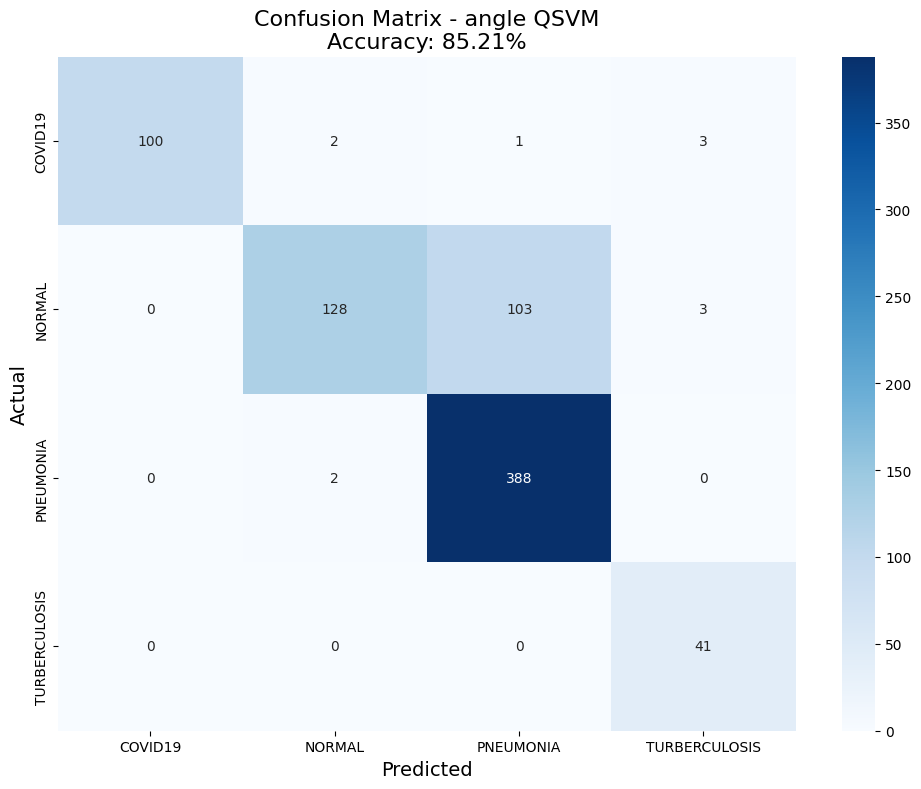

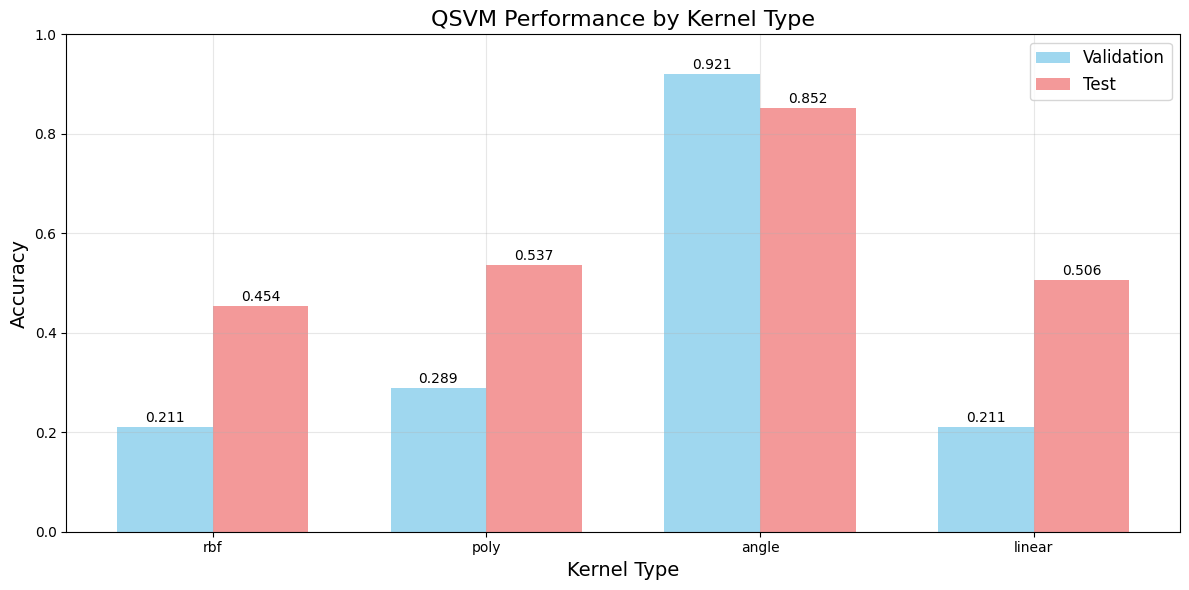

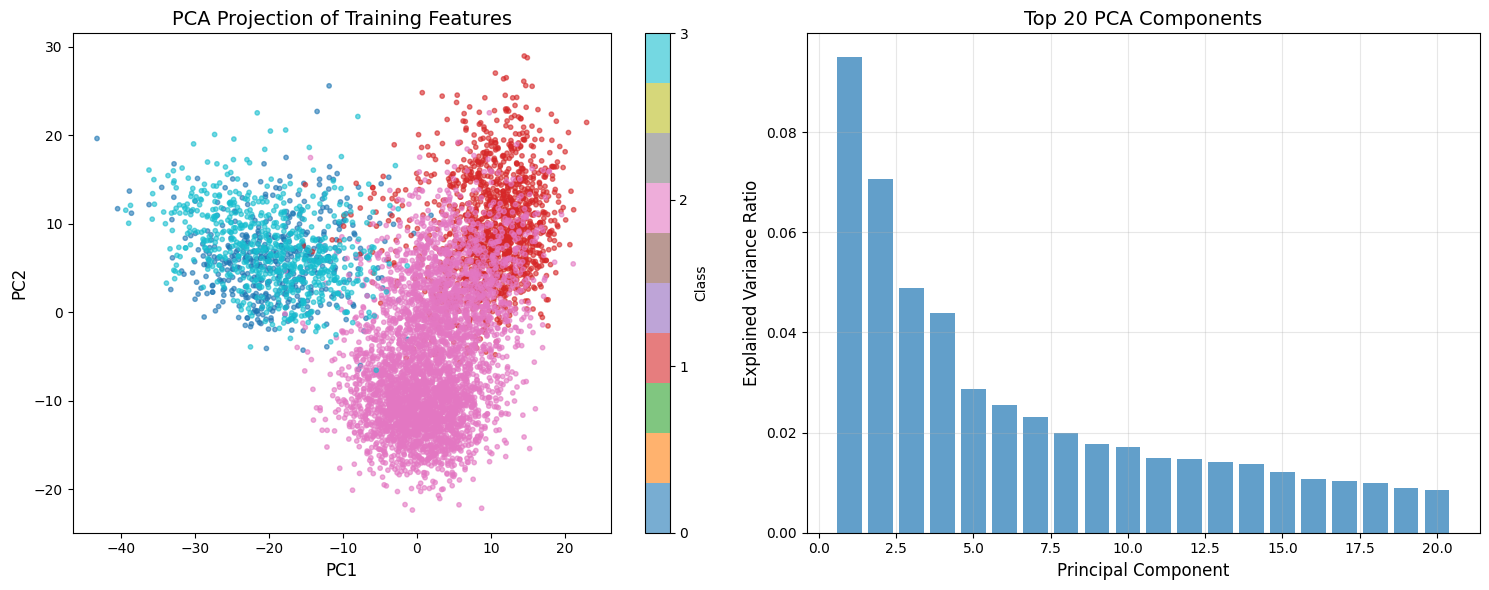

In [10]:

# ============================================================================
# PART 7: VISUALIZATION AND ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("VISUALIZATION AND ANALYSIS")
print("="*60)

# 1. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, test_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title(f'Confusion Matrix - {best_kernel} QSVM\nAccuracy: {test_accuracy_final:.2%}', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'confusion_matrix.png'), dpi=150)
plt.show()

# 2. Kernel comparison bar chart
plt.figure(figsize=(12, 6))
kernels = list(results.keys())
val_scores = [results[k]['val_accuracy'] for k in kernels]
test_scores = [results[k]['test_accuracy'] for k in kernels]

x = np.arange(len(kernels))
width = 0.35

plt.bar(x - width/2, val_scores, width, label='Validation', alpha=0.8, color='skyblue')
plt.bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='lightcoral')

plt.xlabel('Kernel Type', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('QSVM Performance by Kernel Type', fontsize=16)
plt.xticks(x, kernels)
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

for i, (val, test) in enumerate(zip(val_scores, test_scores)):
    plt.text(i - width/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=10)
    plt.text(i + width/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'kernel_comparison.png'), dpi=150)
plt.show()

# 3. PCA visualization (if used)
if use_pca:
    plt.figure(figsize=(15, 6))
    
    # 2D PCA projection
    plt.subplot(1, 2, 1)
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_train_final)
    
    scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                          c=y_train, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, ticks=range(len(class_names)), label='Class')
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.title('PCA Projection of Training Features', fontsize=14)
    
    # Explained variance
    plt.subplot(1, 2, 2)
    plt.bar(range(1, len(pca.explained_variance_ratio_[:20]) + 1), 
            pca.explained_variance_ratio_[:20], alpha=0.7)
    plt.xlabel('Principal Component', fontsize=12)
    plt.ylabel('Explained Variance Ratio', fontsize=12)
    plt.title('Top 20 PCA Components', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'pca_analysis.png'), dpi=150)
    plt.show()

# 4. Feature importance (using SVM weights for linear kernel)
if 'linear' in results:
    linear_qsvm = results['linear']['qsvm']
    
    # For linear kernel, we can extract feature importance
    if hasattr(linear_qsvm.svm, 'coef_'):
        plt.figure(figsize=(12, 6))
        
        # For multi-class, average absolute coefficients
        importance = np.abs(linear_qsvm.svm.coef_).mean(axis=0)
        
        # Sort and plot top features
        top_idx = np.argsort(importance)[-20:]
        top_importance = importance[top_idx]
        
        plt.barh(range(len(top_idx)), top_importance, color='purple', alpha=0.7)
        plt.xlabel('Importance', fontsize=14)
        plt.ylabel('Feature Index', fontsize=14)
        plt.title('Top 20 Feature Importances (Linear QSVM)', fontsize=16)
        plt.yticks(range(len(top_idx)), [f'F{i}' for i in top_idx])
        plt.tight_layout()
        plt.savefig(os.path.join(output_path, 'feature_importance.png'), dpi=150)
        plt.show()



In [11]:

# ============================================================================
# PART 8: SAVE RESULTS AND MODELS
# ============================================================================

print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save results to CSV
results_df = pd.DataFrame([
    {
        'Kernel': k,
        'Validation Accuracy': results[k]['val_accuracy'],
        'Test Accuracy': results[k]['test_accuracy'],
        'Training Time (s)': results[k]['train_time']
    }
    for k in kernels
])
results_df.to_csv(os.path.join(output_path, 'qsvm_results.csv'), index=False)
print(f"Results saved to {output_path}qsvm_results.csv")

# Save best model
import joblib
joblib.dump(final_qsvm, os.path.join(output_path, 'best_qsvm_model.pkl'))
joblib.dump(scaler, os.path.join(output_path, 'scaler.pkl'))
if use_pca:
    joblib.dump(pca, os.path.join(output_path, 'pca.pkl'))
print(f"Best model saved to {output_path}best_qsvm_model.pkl")

# Save predictions
predictions_df = pd.DataFrame({
    'True Label': y_test,
    'True Class': [class_names[i] for i in y_test],
    'Predicted': test_pred_final,
    'Predicted Class': [class_names[i] for i in test_pred_final]
})
predictions_df.to_csv(os.path.join(output_path, 'test_predictions.csv'), index=False)

# Generate summary report
with open(os.path.join(output_path, 'summary_report.txt'), 'w') as f:
    f.write("="*60 + "\n")
    f.write("MOBILENET + QSVM CLASSIFICATION REPORT\n")
    f.write("="*60 + "\n\n")
    
    f.write("Dataset Information:\n")
    f.write(f"  Classes: {class_names}\n")
    f.write(f"  Training samples: {len(trainset)}\n")
    f.write(f"  Validation samples: {len(valset)}\n")
    f.write(f"  Test samples: {len(testset)}\n\n")
    
    f.write("Feature Extraction:\n")
    f.write(f"  Model: MobileNetV2\n")
    f.write(f"  Original feature dimension: {X_train.shape[1]}\n")
    f.write(f"  After scaling: {X_train_scaled.shape[1]}\n")
    if use_pca:
        f.write(f"  After PCA: {X_train_final.shape[1]} (95% variance)\n")
    f.write("\n")
    
    f.write("QSVM Results:\n")
    f.write(f"  Best kernel: {best_kernel}\n")
    f.write(f"  Best parameters: {best_params}\n")
    f.write(f"  Best validation accuracy: {best_score:.4f}\n")
    f.write(f"  Test accuracy: {test_accuracy_final:.4f}\n\n")
    
    f.write("Detailed Test Results:\n")
    f.write(classification_report(y_test, test_pred_final, target_names=class_names))
    f.write("\n" + "="*60 + "\n")

print(f"\nSummary report saved to {output_path}summary_report.txt")
print("\n" + "="*60)
print("PROCESS COMPLETE!")
print("="*60)


SAVING RESULTS
Results saved to ./mobilenet_qsvm_results/qsvm_results.csv
Best model saved to ./mobilenet_qsvm_results/best_qsvm_model.pkl

Summary report saved to ./mobilenet_qsvm_results/summary_report.txt

PROCESS COMPLETE!



COMPARISON WITH CLASSICAL SVM
Classical SVM (RBF) - Validation: 0.9211, Test: 0.8508
QSVM (angle) - Validation: 0.9211, Test: 0.8521


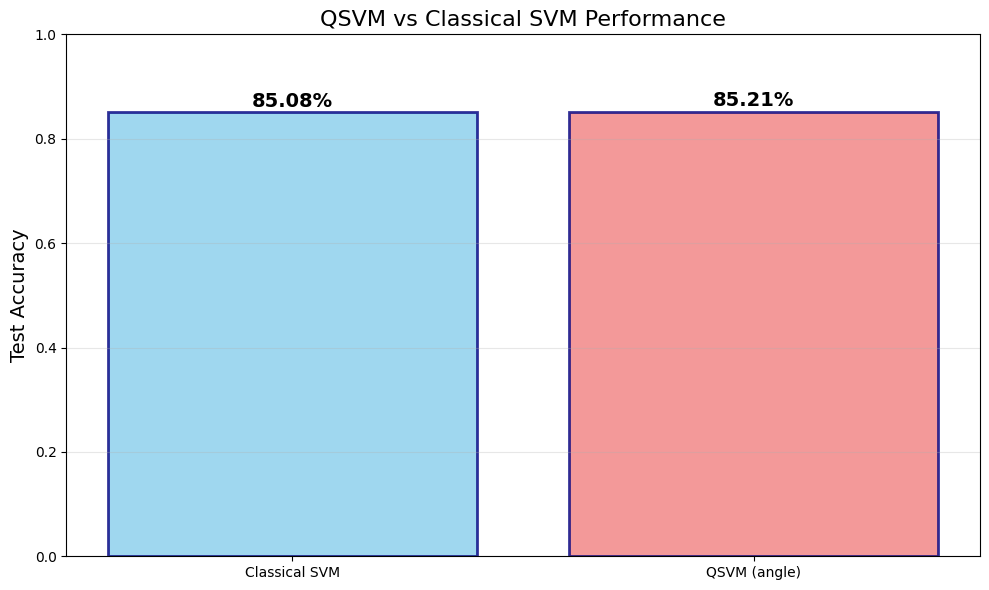


All results saved to: ./mobilenet_qsvm_results/


In [12]:

# ============================================================================
# PART 9: COMPARISON WITH CLASSICAL SVM
# ============================================================================

print("\n" + "="*60)
print("COMPARISON WITH CLASSICAL SVM")
print("="*60)

from sklearn.svm import SVC as ClassicalSVC

# Train classical SVM with RBF kernel
classical_svm = ClassicalSVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
classical_svm.fit(X_train_final, y_train)

# Evaluate
classical_val_pred = classical_svm.predict(X_val_final)
classical_val_acc = accuracy_score(y_val, classical_val_pred)

classical_test_pred = classical_svm.predict(X_test_final)
classical_test_acc = accuracy_score(y_test, classical_test_pred)

print(f"Classical SVM (RBF) - Validation: {classical_val_acc:.4f}, Test: {classical_test_acc:.4f}")
print(f"QSVM ({best_kernel}) - Validation: {best_score:.4f}, Test: {test_accuracy_final:.4f}")

# Comparison plot
plt.figure(figsize=(10, 6))
models = ['Classical SVM', f'QSVM ({best_kernel})']
scores = [classical_test_acc, test_accuracy_final]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(models, scores, color=colors, alpha=0.8, edgecolor='navy', linewidth=2)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.2%}', ha='center', fontsize=14, fontweight='bold')

plt.ylabel('Test Accuracy', fontsize=14)
plt.title('QSVM vs Classical SVM Performance', fontsize=16)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'comparison_svm_vs_qsvm.png'), dpi=150)
plt.show()

print("\n" + "="*60)
print(f"All results saved to: {output_path}")
print("="*60)


EXPLAINABLE AI (XAI) FOR BEST QSVM MODEL

1. Computing permutation feature importance (manual)...


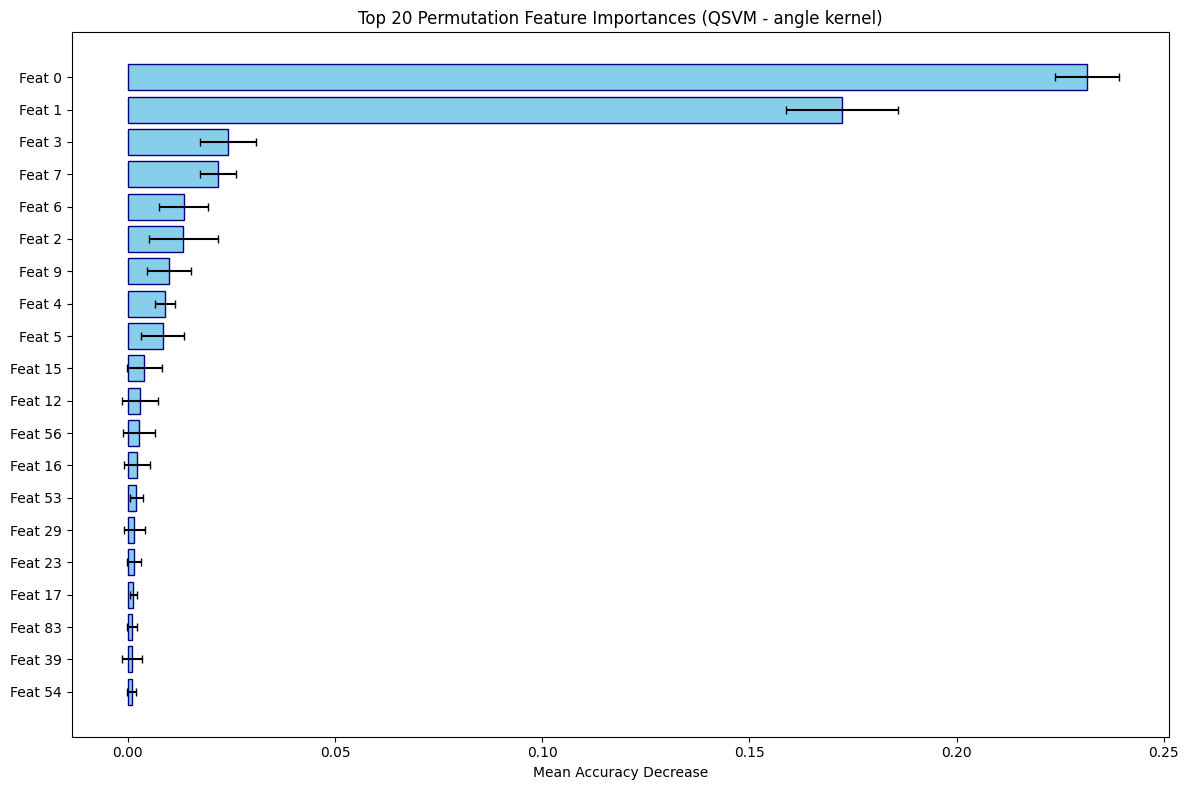

Permutation importance saved to ./mobilenet_qsvm_results/xai_results


In [15]:
# ============================================================================
# PART 10: EXPLAINABLE AI (XAI) FOR QSVM – CORRECTED
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

print("\n" + "="*60)
print("EXPLAINABLE AI (XAI) FOR BEST QSVM MODEL")
print("="*60)

# Ensure we have the best model, scaler, and pca loaded
best_qsvm = final_qsvm
X_train_xai = X_train_final
X_test_xai = X_test_final
y_train_xai = y_train
y_test_xai = y_test
class_names = class_names

# Create output directory for XAI results
xai_dir = os.path.join(output_path, 'xai_results')
os.makedirs(xai_dir, exist_ok=True)

# ----------------------------------------------------------------------------
# 1. Manual Permutation Feature Importance (model agnostic)
# ----------------------------------------------------------------------------
print("\n1. Computing permutation feature importance (manual)...")

def permutation_importance_manual(estimator, X, y, n_repeats=10, random_state=42):
    """
    Manually compute permutation importance for any estimator with .predict()
    Returns:
        importances_mean : array of shape (n_features,)
        importances_std  : array of shape (n_features,)
    """
    rng = np.random.RandomState(random_state)
    baseline_score = accuracy_score(y, estimator.predict(X))
    n_features = X.shape[1]
    importances = np.zeros(n_features)
    importances_std = np.zeros(n_features)

    for col in range(n_features):
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, col] = rng.permutation(X_permuted[:, col])
            score = accuracy_score(y, estimator.predict(X_permuted))
            scores.append(score)
        importances[col] = baseline_score - np.mean(scores)
        importances_std[col] = np.std(scores)

    return importances, importances_std

# Compute permutation importance on test set
imp_mean, imp_std = permutation_importance_manual(
    best_qsvm, X_test_xai, y_test_xai, n_repeats=10, random_state=42
)

# Sort features by importance
sorted_idx = np.argsort(imp_mean)[::-1]
top_n = min(20, len(sorted_idx))

plt.figure(figsize=(12, 8))
plt.barh(range(top_n), imp_mean[sorted_idx[:top_n]], 
         xerr=imp_std[sorted_idx[:top_n]], 
         color='skyblue', edgecolor='navy', capsize=3)
plt.yticks(range(top_n), [f'Feat {i}' for i in sorted_idx[:top_n]])
plt.xlabel('Mean Accuracy Decrease')
plt.title(f'Top {top_n} Permutation Feature Importances (QSVM - {best_kernel} kernel)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(xai_dir, 'permutation_importance.png'), dpi=150)
plt.show()

# Save importance values to CSV
importance_df = pd.DataFrame({
    'feature_idx': sorted_idx,
    'importance_mean': imp_mean[sorted_idx],
    'importance_std': imp_std[sorted_idx]
})
importance_df.to_csv(os.path.join(xai_dir, 'permutation_importance.csv'), index=False)
print(f"Permutation importance saved to {xai_dir}")
